# TFT mit Geo-Embedding und Wind — Beijing Air Quality

**Ziel:** Wir bringen den Ansatz aus dem Paper *"A novel ST-iTransformer model for spatio-temporal ambient air pollution forecasting"* (Zhang & Awang, 2025) in ein **Temporal Fusion Transformer (TFT)** Modell ein — und zwar die zwei Dinge, nach denen gefragt wurde:

1. **Wind** (Windgeschwindigkeit `WSPM`) als meteorologische Eingangsvariable.
2. **Geo-Embedding** — die geografische Lage jeder Station (Laengengrad `lon`, Breitengrad `lat`).

### Die zentrale Idee (bitte zuerst lesen)

Der TFT hat fuer beides schon eingebaute "Steckplaetze". Wir muessen **kein eigenes Netzwerk programmieren** — wir muessen die Variablen nur richtig *deklarieren*:

| Was | Rolle im echten Leben | TFT-Kategorie |
|-----|----------------------|---------------|
| Wind `WSPM`, Temp, Taupunkt, andere Schadstoffe | aendern sich ueber Zeit, kennen wir nur bis *jetzt* | `time_varying_unknown_reals` |
| Zeit-Merkmale (Stunde, Wochentag) | aendern sich ueber Zeit, kennen wir auch fuer die Zukunft | `time_varying_known_reals` |
| **`lon`, `lat`** der Station | aendern sich **nie**, gehoeren zur Station | `static_reals` ← **das ist unser Geo-Embedding** |
| Stationsname | Gruppierungs-ID | `group_ids` + `static_categoricals` |

**Bezug zum Paper:** Das Paper bildet das End-Embedding als `H = H_T + L'_s`, wobei `H_T` die Zeitreihe und `L'_s` eine lineare Projektion von (lon, lat) ist. Im TFT uebernimmt der **Static Covariate Encoder** genau diese Rolle: Er projiziert `lon`/`lat` in einen Vektor und speist ihn in alle Teile des Netzes ein. Konzeptionell ist das dasselbe wie `L'_s` im Paper. Weiter unten zeige ich fuer Interessierte zusaetzlich ein *explizites* Geo-Embedding als eigene PyTorch-Schicht (Anhang).

> Hinweis: Dieses Notebook ist als **Tutorial** geschrieben — mit vielen Kommentaren. Zellen der Reihe nach von oben nach unten ausfuehren.

## 0. Installation

Einmalig ausfuehren. Falls du Anaconda nutzt, kannst du das auch im Terminal machen.
`pytorch-forecasting` ist versionsempfindlich — deshalb installieren wir passende Versionen zusammen.

In [ ]:
# Einmalig ausfuehren (dann kannst du die Zelle auskommentieren).
# Bei Problemen: Kernel neu starten nach der Installation.
%pip install -q "torch>=2.0" "lightning>=2.0" "pytorch-forecasting>=1.0" pandas numpy matplotlib
print("Installation fertig. Bitte ggf. den Kernel neu starten (Kernel -> Restart).")

## 1. Bibliotheken importieren

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

pl.seed_everything(42)          # Reproduzierbarkeit

# Tensor-Cores der GPU besser nutzen -> schnelleres Training, minimaler Genauigkeitsverlust
# (genau das schlaegt auch die Lightning-Warnung im Log vor)
torch.set_float32_matmul_precision("medium")

print("torch:", torch.__version__)
print("GPU verfuegbar:", torch.cuda.is_available())

## 2. Daten laden

Wir benutzen den **"Beijing Multi-Site Air Quality"**-Datensatz (12 Stationen, 2013-2017),
denselben wie im Paper. Er besteht aus 12 CSV-Dateien (eine pro Station).

Die Zelle versucht zuerst, den Datensatz von der UCI-Seite herunterzuladen.
**Falls das fehlschlaegt** (z. B. kein Internet), erzeugt sie automatisch einen kleinen
**synthetischen Ersatz-Datensatz mit identischer Struktur**, damit das Notebook trotzdem
komplett durchlaeuft. Fuer echte Ergebnisse ladet die echten Daten.

In [ ]:
import io, zipfile, urllib.request, os

DATA_DIR = "beijing_data"
UCI_URL = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"

STATIONS = ["Aotizhongxin","Changping","Dingling","Dongsi","Guanyuan","Gucheng",
            "Huairou","Nongzhanguan","Shunyi","Tiantan","Wanliu","Wanshouxigong"]

def try_download_real_data():
    "Laedt die echten UCI-CSV-Dateien herunter und entpackt sie. Gibt True zurueck bei Erfolg."
    try:
        print("Lade UCI-Datensatz herunter ...")
        raw = urllib.request.urlopen(UCI_URL, timeout=30).read()
        z = zipfile.ZipFile(io.BytesIO(raw))
        # Das UCI-Zip enthaelt ein weiteres Zip / einen Ordner mit CSVs -> alle CSVs extrahieren
        os.makedirs(DATA_DIR, exist_ok=True)
        for name in z.namelist():
            if name.endswith(".zip"):
                inner = zipfile.ZipFile(io.BytesIO(z.read(name)))
                inner.extractall(DATA_DIR)
            elif name.endswith(".csv"):
                z.extract(name, DATA_DIR)
        print("Download OK.")
        return True
    except Exception as e:
        print("Download fehlgeschlagen:", e)
        return False

def load_real_csvs():
    "Sucht die 12 PRSA_Data_*.csv und stapelt sie untereinander."
    import glob
    files = glob.glob(os.path.join(DATA_DIR, "**", "PRSA_Data_*.csv"), recursive=True)
    if len(files) < 12:
        return None
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

def make_synthetic():
    "Erzeugt Demo-Daten mit derselben Spaltenstruktur wie das echte Dataset."
    print(">>> Nutze SYNTHETISCHE Demo-Daten (nur zum Testen, keine echten Werte!) <<<")
    rng = np.random.default_rng(0)
    frames = []
    hours = pd.date_range("2013-03-01", periods=24*40, freq="h")  # 40 Tage
    for i, st in enumerate(STATIONS):
        n = len(hours)
        # simpler Tagesgang + Rauschen, damit ein Modell ueberhaupt etwas lernen kann
        daily = 30*np.sin(2*np.pi*hours.hour/24)
        frames.append(pd.DataFrame({
            "year":hours.year,"month":hours.month,"day":hours.day,"hour":hours.hour,
            "PM2.5":(80+daily+rng.normal(0,15,n)).clip(1),
            "PM10":(100+daily+rng.normal(0,20,n)).clip(1),
            "SO2":rng.normal(15,5,n).clip(0),"NO2":rng.normal(50,15,n).clip(0),
            "O3":rng.normal(60,20,n).clip(0),
            "TEMP":13+10*np.sin(2*np.pi*hours.dayofyear/365)+rng.normal(0,2,n),
            "DEWP":rng.normal(2,5,n),"RAIN":0.0,
            "wd":rng.choice(["N","NE","E","SE","S","SW","W","NW"],n),
            "WSPM":rng.normal(2,1,n).clip(0),"station":st}))
    return pd.concat(frames, ignore_index=True)

# --- Ablauf ---
raw = None
if try_download_real_data():
    raw = load_real_csvs()
if raw is None:
    raw = make_synthetic()

print("Roh-Datensatz (alle Stationen gestapelt):", raw.shape)
raw.head()

## 3. Vorverarbeitung: Zeitstempel, `time_idx` und Wind

Zwei Dinge, die der TFT zwingend braucht:

- **`time_idx`**: eine fortlaufende ganze Zahl je Zeitschritt (0,1,2,...). Der TFT misst Abstaende darueber.
- Eine **Gruppen-Spalte** (`station`), damit er die 12 Zeitreihen auseinanderhaelt.

Der **Wind** steckt schon in Spalte `WSPM` (Windgeschwindigkeit in m/s). Zusaetzlich gibt es
`wd` = Windrichtung (Kategorie wie "NW"). Windrichtung nehmen wir optional als **kategoriale**
Variable mit — sie kann helfen, die Transport-Richtung der Schadstoffe zu lernen (das West->Ost-
Beispiel aus dem Paper).

In [ ]:
df = raw.copy()

# 1) Zeitstempel bauen
df["datetime"] = pd.to_datetime(df[["year","month","day","hour"]])

# 2) sortieren und fortlaufenden globalen time_idx erzeugen (gleiche Uhr fuer alle Stationen)
df = df.sort_values(["station","datetime"]).reset_index(drop=True)
df["time_idx"] = ((df["datetime"] - df["datetime"].min()).dt.total_seconds() // 3600).astype(int)

# 3) bekannte Zeit-Merkmale (kennen wir auch fuer die Zukunft!)
df["hour"]      = df["datetime"].dt.hour
df["dayofweek"] = df["datetime"].dt.dayofweek

# 4) Windrichtung als String (kategorial). Fehlende -> "unknown"
df["wd"] = df["wd"].astype(str).fillna("unknown").replace("nan","unknown")

# 5) fehlende Zahlenwerte je Station zeitlich auffuellen (vor/zurueck) — einfache, robuste Methode
num_cols = ["PM2.5","PM10","SO2","NO2","O3","TEMP","DEWP","RAIN","WSPM"]
num_cols = [c for c in num_cols if c in df.columns]
df[num_cols] = (df.groupby("station")[num_cols]
                  .apply(lambda g: g.ffill().bfill())
                  .reset_index(level=0, drop=True))
df[num_cols] = df[num_cols].fillna(0)

# 6) pytorch-forecasting (neue Version) verbietet Punkte in Spaltennamen -> PM2.5 zu PM25 umbenennen
df = df.rename(columns={"PM2.5": "PM25"})
num_cols = ["PM25" if c == "PM2.5" else c for c in num_cols]

print("Fehlende Werte nach dem Auffuellen:", int(df[num_cols].isna().sum().sum()))
df[["datetime","station","time_idx","PM25","WSPM","wd","hour","dayofweek"]].head()

## 4. Geo-Embedding vorbereiten: Koordinaten je Station

Wir haengen an **jede Zeile** die geografische Lage ihrer Station. Weil `lon`/`lat`
sich ueber die Zeit nie aendern, werden sie spaeter als **`static_reals`** deklariert -
der TFT projiziert sie dann intern in einen Vektor (= das Geo-Embedding aus dem Paper).

> **Datenquelle:** Die UCI-CSV-Dateien enthalten **keine** Koordinaten. Wir laden sie deshalb
> aus `data/stations_geo.csv`. Die Werte sind die **offiziellen Koordinaten aller 12 Stationen
> aus Tsokov et al. (2022), *Sustainability* 14(9):5104, Table 1** und wurden 1:1 gegen die
> Publikation verifiziert (Uebereinstimmung auf 3 Dezimalstellen). Damit sind sie fuer die
> finale Abgabe zitierfaehig.


In [ ]:
# Stationskoordinaten aus gepruefter CSV laden (statt hartkodiert im Code).
# Quelle/Pruefung: siehe data/stations_geo.csv (Spalte "source").
# Vorteil: Koordinaten sind versioniert und leicht austauschbar, ohne den Code zu aendern.
import os

# Pfad zur CSV relativ zum notebooks-Ordner. Falls dein Notebook woanders liegt,
# passe den Pfad an (z. B. auf einen absoluten Pfad).
geo_path = os.path.join("..", "data", "stations_geo.csv")
coord_df = pd.read_csv(geo_path)[["station", "lon", "lat"]]

print("Koordinaten geladen aus:", geo_path)
print("Anzahl Stationen in der CSV:", coord_df["station"].nunique())

# An jede Datenzeile die Lage ihrer Station anhaengen
df = df.merge(coord_df, on="station", how="left")

# Koordinaten normalisieren (0..1) - hilft dem TFT-Training (lineare Projektion ins Embedding)
for c in ["lon", "lat"]:
    lo, hi = df[c].min(), df[c].max()
    df[c + "_norm"] = (df[c] - lo) / (hi - lo + 1e-9)

# Sicherheitscheck: es darf keine Station ohne Koordinaten geben
fehlend = df[df["lon"].isna()]["station"].unique()
assert len(fehlend) == 0, f"Es fehlen Koordinaten fuer: {fehlend}"

print("Koordinaten gemerged. Stationen gesamt:", df["station"].nunique())
df[["station", "lon", "lat", "lon_norm", "lat_norm"]].drop_duplicates().reset_index(drop=True)

### Kurzer Blick auf die Geografie
So sind die Stationen raeumlich verteilt — genau diese Information gibt das Geo-Embedding dem Modell.

In [ ]:
plt.figure(figsize=(5,5))
sub = df[["station","lon","lat"]].drop_duplicates()
plt.scatter(sub["lon"], sub["lat"], s=60)
for _, r in sub.iterrows():
    plt.annotate(r["station"], (r["lon"], r["lat"]), fontsize=8, xytext=(3,3),
                 textcoords="offset points")
plt.xlabel("Laengengrad (lon)"); plt.ylabel("Breitengrad (lat)")
plt.title("Lage der 12 Messstationen in Beijing"); plt.grid(alpha=.3); plt.show()

## 5. Das `TimeSeriesDataSet` bauen — hier passiert die Zuordnung

Diese Zelle ist das **Herzstueck**. Hier sagen wir dem TFT, welche Spalte welche Rolle hat.
Achte besonders auf die drei markierten Zeilen: **Ziel**, **Wind** und **Geo-Embedding**.

**Train/Test-Split (echter Zeitraum):** Wir halten die **letzten 14 Tage** je Station als
Test-Zeitraum zurueck. Trainiert wird nur auf den Daten davor. Der Test besteht aus
**rollierenden 12-Stunden-Fenstern** ueber diese 14 Tage — dadurch werden die Kennzahlen
(MAE/RMSE/MASE) auf vielen tausend Punkten berechnet statt nur auf dem allerletzten Fenster.

In [ ]:
max_encoder_length = 48   # wie viele Stunden Vergangenheit das Modell sieht (2 Tage)
max_prediction_length = 12  # wie viele Stunden es vorhersagt (wie k im Paper)

target = "PM25"            # <<< ZIEL: was wir vorhersagen (PM2.5 wurde zu PM25 umbenannt, keine Punkte erlaubt)

# --- Zeitlicher Train/Test-Split: die letzten Tage als echter Test-Zeitraum ---
test_days   = 14                       # Laenge des Test-Zeitraums (in Tagen) -- bei Bedarf aendern
test_length = test_days * 24           # in Stunden (stuendliche Daten)
training_cutoff = df["time_idx"].max() - test_length

training = TimeSeriesDataSet(
    df[df["time_idx"] <= training_cutoff],   # NUR Daten vor dem Test-Zeitraum
    time_idx="time_idx",
    target=target,
    group_ids=["station"],                     # jede Station = eigene Zeitreihe
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    # --- STATISCHE Merkmale der Station ---
    static_categoricals=["station"],
    static_reals=["lon_norm", "lat_norm"],     # <<< GEO-EMBEDDING: Koordinaten der Station

    # --- ZEITVARIABLE, in der Zukunft bekannte Merkmale ---
    time_varying_known_reals=["time_idx", "hour", "dayofweek"],

    # --- ZEITVARIABLE, nur bis "jetzt" bekannte Merkmale ---
    time_varying_unknown_reals=[
        "PM25", "PM10", "SO2", "NO2", "O3",    # Schadstoffe (PM2.5 -> PM25)
        "TEMP", "DEWP", "RAIN",                # Wetter
        "WSPM",                                 # <<< WIND (Windgeschwindigkeit)
    ],
    time_varying_unknown_categoricals=["wd"],  # Windrichtung (kategorial), optional

    # Ziel je Station getrennt normalisieren (Stationen haben unterschiedliche Niveaus)
    target_normalizer=GroupNormalizer(groups=["station"]),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True,
)

# Test-Set: ROLLIERENDE Fenster ueber den gesamten Test-Zeitraum (nicht nur das letzte).
# min_prediction_idx sorgt dafuer, dass alle vorhergesagten Stunden NACH dem Trainingsende liegen;
# der 48h-Encoder darf in den Trainingszeitraum zurueckreichen (das ist normal und erlaubt).
validation = TimeSeriesDataSet.from_dataset(
    training, df,
    min_prediction_idx=training_cutoff + 1,
    stop_randomization=True,
)

print(f"Test-Zeitraum: letzte {test_days} Tage ({test_length} Stunden) je Station")
print("Trainings-Samples:", len(training), "| Test-Samples:", len(validation))

### Warum ist das schon das Geo-Embedding?

`static_reals=["lon_norm","lat_norm"]` → der TFT schickt diese zwei Zahlen durch seinen
**Static Covariate Encoder** (eine kleine Feed-Forward-Schicht mit GLU/Gating). Ergebnis ist ein
Vektor, der — genau wie `L'_s` im Paper — in die Verarbeitung jeder Station einfliesst und
Kontext-Vektoren fuer Encoder, Decoder und die Variablen-Selektion liefert. Wir mussten dafuer
keinen Netzwerk-Code schreiben.

## 6. DataLoader und Modell erstellen

In [ ]:
batch_size = 128   # groesser = bessere GPU-Auslastung. Bei "CUDA out of memory" auf 64 reduzieren.
train_dataloader = training.to_dataloader(train=True,  batch_size=batch_size, num_workers=0)
val_dataloader   = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.03,
    hidden_size=64,             # groesser fuers echte Training (Tutorial-Demo war 32)
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    loss=QuantileLoss(),        # gibt Vorhersage-Intervalle statt nur einen Punkt
    optimizer="adam",
    reduce_on_plateau_patience=4,   # senkt die Lernrate automatisch, wenn es stockt
)
print(f"Modell erstellt. Anzahl Parameter: {tft.size()/1e3:.1f}k")

## 7. Training

Fuers Tutorial nur wenige Epochen. Auf einer GPU geht es schneller; auf CPU dauert es etwas.
Erhoeht `max_epochs` fuer bessere Ergebnisse.

In [ ]:
from lightning.pytorch.callbacks import ModelCheckpoint

early_stop = EarlyStopping(monitor="val_loss", patience=5, mode="min")
checkpoint = ModelCheckpoint(monitor="val_loss", mode="min", save_top_k=1)  # merkt sich das BESTE Modell

trainer = pl.Trainer(
    max_epochs=30,                # echtes Training (Demo war 5); EarlyStopping stoppt frueher, falls noetig
    accelerator="auto",           # nutzt automatisch die NVIDIA-GPU
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop, checkpoint],
    enable_progress_bar=True,
    logger=False,
)

trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)
print("Training fertig.")
print("Bestes Modell gespeichert unter:", checkpoint.best_model_path)

## 8. Vorhersage und Plot

Wir sagen die naechsten Stunden fuer eine Station voraus und zeichnen sie mit Unsicherheitsband.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


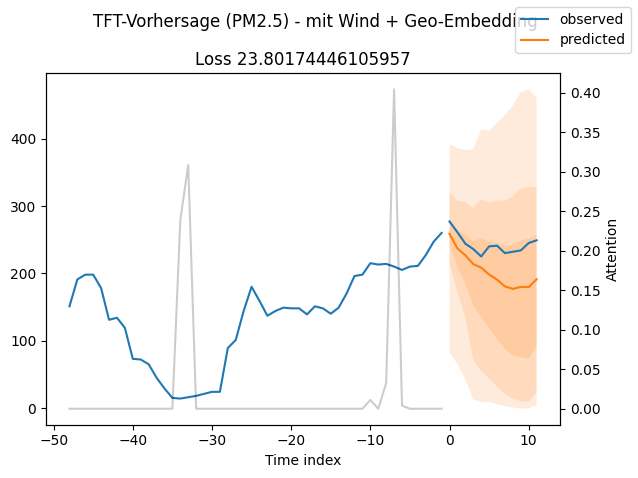

In [15]:
# Bestes Modell aus dem Training laden (nicht das der letzten Epoche)
best_model_path = checkpoint.best_model_path
if best_model_path:
    best_model = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
else:
    best_model = tft   # Fallback, falls kein Checkpoint gespeichert wurde

# Vorhersagen inkl. Rohdaten fuer den Plot
raw_predictions = best_model.predict(val_dataloader, mode="raw", return_x=True)

# Plot fuer die erste Station im Batch
best_model.plot_prediction(raw_predictions.x, raw_predictions.output, idx=0, add_loss_to_title=True)
plt.suptitle("TFT-Vorhersage (PM2.5) - mit Wind + Geo-Embedding")
plt.tight_layout(); plt.show()

## 8b. Fehlerkennzahlen auf dem Test-Zeitraum

Die Plots zeigen den Verlauf - hier bekommen wir die **Zahlen**. MAE und RMSE stehen in
ug/m3 (gleiche Einheit wie PM2.5), sind also direkt interpretierbar. Zum Einordnen: das
Referenz-Paper erreicht fuer die getesteten Stationen MAE-Werte im Bereich von etwa 17-20 ug/m3.

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE  :  26.31 ug/m3
RMSE :  43.09 ug/m3
MAPE : 168.01 %


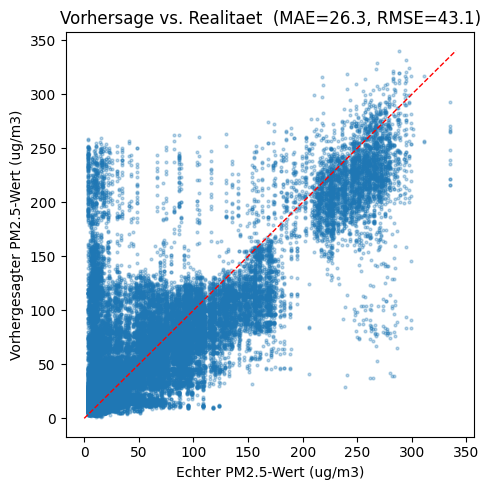

In [16]:
import numpy as np

# Punktvorhersagen und die echten Werte holen
pred   = best_model.predict(val_dataloader, mode="prediction", return_y=True)
y_pred = pred.output.detach().cpu().numpy().reshape(-1)
y_true = pred.y[0].detach().cpu().numpy().reshape(-1)

mae  = np.mean(np.abs(y_pred - y_true))
rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
# MAPE: sehr kleine Ist-Werte abfangen, damit die Prozente nicht explodieren
mape = np.mean(np.abs(y_pred - y_true) / np.clip(np.abs(y_true), 1, None)) * 100

print(f"MAE  : {mae:6.2f} ug/m3")
print(f"RMSE : {rmse:6.2f} ug/m3")
print(f"MAPE : {mape:6.2f} %")

# Streudiagramm: Vorhersage vs. echter Wert (perfekt = Punkte auf der roten Diagonale)
plt.figure(figsize=(5, 5))
plt.scatter(y_true, y_pred, s=4, alpha=0.3)
lim = [0, float(max(y_true.max(), y_pred.max()))]
plt.plot(lim, lim, "r--", linewidth=1)
plt.xlabel("Echter PM2.5-Wert (ug/m3)")
plt.ylabel("Vorhergesagter PM2.5-Wert (ug/m3)")
plt.title(f"Vorhersage vs. Realitaet  (MAE={mae:.1f}, RMSE={rmse:.1f})")
plt.tight_layout(); plt.show()

### Fehler pro Station (MAE, Naive-Baseline, MASE, RMSE, MAPE) + CSV-Export

Ein Gesamtwert verdeckt, dass manche Stationen leichter vorherzusagen sind als andere.
Neben MAE/RMSE zeigen wir die **Naive-Baseline** (`MAE_naive24h` = Fehler der saisonalen
24h-Vorhersage je Station) direkt als eigene Spalte — daraus ergibt sich **MASE = MAE / MAE_naive24h**.
So ist auf einen Blick belegt, um wieviel das Modell die naive Referenz schlaegt (**MASE < 1 = besser**).
**MAPE** ist bei PM2.5 mit Vorsicht zu geniessen (kleine Ist-Werte blaehen die Prozente auf).
Die Tabelle wird als `data/ergebnis_tft_geo_metriken.csv` gespeichert.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Fehlerkennzahlen je Station (MASE = MAE / MAE_naive24h; < 1 = besser als naive):

      Station  n_Fenster       MAE  MAE_naive24h  MASE      RMSE  MAPE_%
      Huairou        325 22.639999        51.587 0.439 35.632000 152.943
     Dingling        325 23.389000        52.742 0.443 41.455002 170.186
    Changping        325 24.396999        52.800 0.462 41.837002 125.286
       Wanliu        325 24.676001        59.661 0.414 39.777000 177.720
 Nongzhanguan        325 25.937000        63.124 0.411 40.738998 153.762
Wanshouxigong        325 26.688999        62.953 0.424 40.922001 137.724
     Guanyuan        325 26.740999        58.826 0.455 43.608002 181.634
      Gucheng        325 27.023001        59.514 0.454 44.013000 133.187
       Shunyi        325 27.403000        59.751 0.459 43.338001 168.406
      Tiantan        325 27.721001        59.428 0.466 45.449001 202.169
 Aotizhongxin        325 28.330999        59.871 0.473 47.089001 188.150
       Dongsi        325 30.757999        

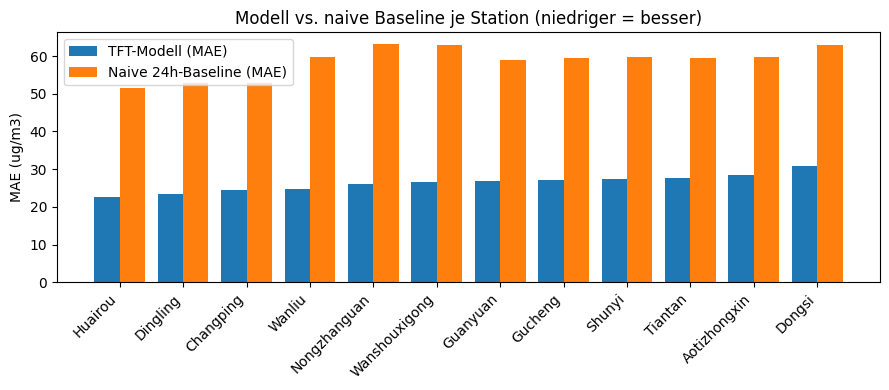

In [17]:
import os
import numpy as np
import pandas as pd

# --- 1) Vorhersagen inkl. Stations-Zuordnung holen ---
pred_s = best_model.predict(val_dataloader, mode="prediction", return_y=True, return_index=True)
yp = pred_s.output.detach().cpu().numpy()      # Form: (Anzahl_Fenster, Vorhersage-Horizont)
yt = pred_s.y[0].detach().cpu().numpy()        # gleiche Form
stations = pred_s.index["station"].to_numpy()  # Station je Vorhersage-Fenster

# --- 2) NAIVE BASELINE je Station: saisonaler 24h-Naive-Fehler AUF DEN TRAININGSDATEN ---
# Naive-Vorhersage = "der Wert ist wie vor 24 h". Ihr mittlerer Fehler ist der MASE-Massstab.
# MASE = MAE(Modell) / MAE(naive):  < 1 bedeutet, das Modell schlaegt die naive Referenz.
SEASON = 24   # Saisonperiode in Stunden (24 = Tagesgang). Fuer Wochengang: 24*7.
train_df = df[df["time_idx"] <= training_cutoff]
scale = {}
for st, g in train_df.sort_values("time_idx").groupby("station"):
    diffs = g[target].diff(SEASON).abs().dropna()   # |Wert(t) - Wert(t-24h)|
    scale[st] = diffs.mean()                         # = MAE der naiven 24h-Vorhersage

# --- 3) Kennzahlen je Station berechnen ---
rows = []
for st in np.unique(stations):
    m = stations == st
    a = yp[m].reshape(-1)          # vorhergesagte Werte dieser Station
    b = yt[m].reshape(-1)          # echte Werte dieser Station
    mae   = np.mean(np.abs(a - b))
    rmse  = np.sqrt(np.mean((a - b) ** 2))
    mape  = np.mean(np.abs(a - b) / np.clip(np.abs(b), 1, None)) * 100   # kleine Ist-Werte abfangen
    naive = scale.get(st, np.nan)  # MAE der naiven 24h-Baseline
    mase  = mae / naive if naive else np.nan                            # <1 = besser als naive
    rows.append({"Station": st, "n_Fenster": int(m.sum()),
                 "MAE": mae, "MAE_naive24h": naive, "MASE": mase,
                 "RMSE": rmse, "MAPE_%": mape})

metrics_df = pd.DataFrame(rows).sort_values("MAE").reset_index(drop=True)

# --- 4) Gesamtzeile (MAE/RMSE gepoolt, Naive/MASE/MAPE als Mittel ueber die Stationen) ---
a_all, b_all = yp.reshape(-1), yt.reshape(-1)
naive_mean = float(np.mean([scale[s] for s in np.unique(stations)]))
gesamt = {
    "Station": "GESAMT",
    "n_Fenster": int(len(stations)),
    "MAE": np.mean(np.abs(a_all - b_all)),
    "MAE_naive24h": naive_mean,
    "MASE": metrics_df["MASE"].mean(),
    "RMSE": np.sqrt(np.mean((a_all - b_all) ** 2)),
    "MAPE_%": metrics_df["MAPE_%"].mean(),
}
metrics_df = pd.concat([metrics_df, pd.DataFrame([gesamt])], ignore_index=True)

# Spaltenreihenfolge fuer die Praesentation
metrics_df = metrics_df[["Station", "n_Fenster", "MAE", "MAE_naive24h", "MASE", "RMSE", "MAPE_%"]]

# --- 5) Ausgabe + CSV-Export ---
print("Fehlerkennzahlen je Station (MASE = MAE / MAE_naive24h; < 1 = besser als naive):\n")
print(metrics_df.round(3).to_string(index=False))

out_path = os.path.join("..", "data", "ergebnis_tft_geo_metriken.csv")
metrics_df.round(4).to_csv(out_path, index=False)
print("\nGespeichert unter:", out_path)

# --- 6) Balkendiagramm: Modell-MAE vs. Naive-Baseline je Station ---
plot_df = metrics_df[metrics_df["Station"] != "GESAMT"]
x = np.arange(len(plot_df)); w = 0.4
plt.figure(figsize=(9, 4))
plt.bar(x - w/2, plot_df["MAE"],          w, label="TFT-Modell (MAE)")
plt.bar(x + w/2, plot_df["MAE_naive24h"], w, label="Naive 24h-Baseline (MAE)")
plt.xticks(x, plot_df["Station"], rotation=45, ha="right")
plt.ylabel("MAE (ug/m3)")
plt.title("Modell vs. naive Baseline je Station (niedriger = besser)")
plt.legend(); plt.tight_layout(); plt.show()

## 9. Beweis, dass Wind und Geo genutzt werden — Variablen-Wichtigkeit

Der grosse Vorteil des TFT: Er ist **interpretierbar**. Wir lesen aus, wie stark jede Variable
beitraegt — als **Prozent-Anteil** innerhalb ihrer Gruppe. Erwartung:

- Bei den **Encoder-Variablen** (Vergangenheit) sollte `WSPM` (Wind) einen sichtbaren Anteil haben.
- Bei den **statischen Variablen** (Station) sollten `lon`/`lat` auftauchen — das ist der direkte
  Beleg, dass das **Geo-Embedding** tatsaechlich genutzt wird.

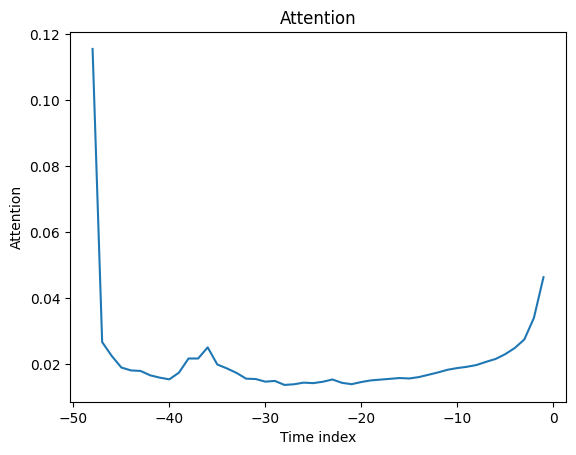

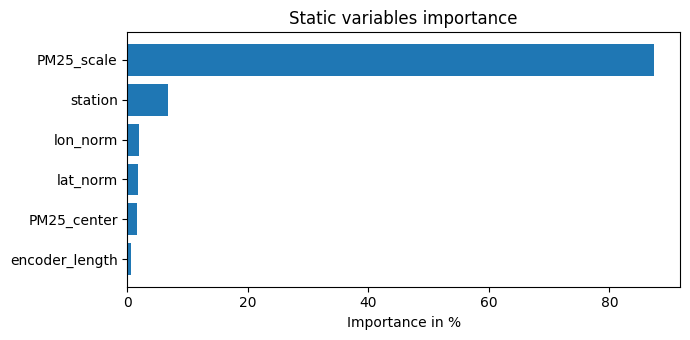

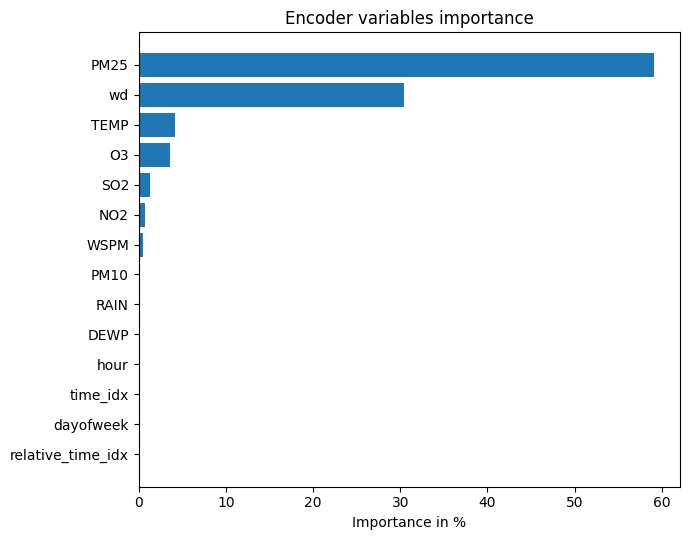

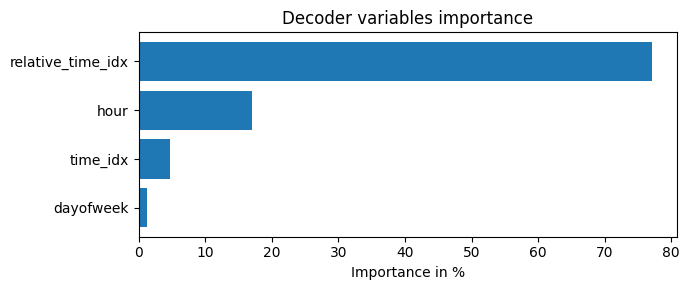

Encoder-Variablen (Vergangenheit, u.a. WSPM = Wind):
  PM25                  :  59.1 %
  wd                    :  30.4 %
  TEMP                  :   4.2 %
  O3                    :   3.6 %
  SO2                   :   1.2 %
  NO2                   :   0.7 %
  WSPM                  :   0.5 %
  PM10                  :   0.1 %
  RAIN                  :   0.0 %
  DEWP                  :   0.0 %
  hour                  :   0.0 %
  time_idx              :   0.0 %
  dayofweek             :   0.0 %
  relative_time_idx     :   0.0 %

Statische (Stations-)Variablen (Geo: lon_norm / lat_norm):
  PM25_scale            :  87.4 %
  station               :   6.8 %
  lon_norm              :   2.0 %
  lat_norm              :   1.7 %
  PM25_center           :   1.7 %
  encoder_length        :   0.5 %



In [18]:
import numpy as np

interpretation = best_model.interpret_output(raw_predictions.output, reduction="sum")
best_model.plot_interpretation(interpretation)
plt.show()

def zeige_wichtigkeit(titel, namen, werte):
    "Gibt die Variablen-Wichtigkeit als Prozent-Rangliste aus."
    werte = np.asarray(werte, dtype=float)
    summe = werte.sum()
    prozent = 100 * werte / summe if summe > 0 else werte
    print(titel)
    for n, p in sorted(zip(namen, prozent), key=lambda t: -t[1]):
        print(f"  {n:22s}: {p:5.1f} %")
    print()

# Encoder-Variablen = Vergangenheit; hier steckt der Wind WSPM
zeige_wichtigkeit("Encoder-Variablen (Vergangenheit, u.a. WSPM = Wind):",
                  best_model.encoder_variables,
                  interpretation["encoder_variables"].detach().cpu().numpy())

# Statische Variablen = Station; hier steckt das Geo-Embedding lon/lat
zeige_wichtigkeit("Statische (Stations-)Variablen (Geo: lon_norm / lat_norm):",
                  best_model.static_variables,
                  interpretation["static_variables"].detach().cpu().numpy())

## Anhang (optional): Explizites Geo-Embedding wie im Paper

Falls ihr **keinen** `pytorch-forecasting`-TFT nutzt, sondern euren *eigenen* Transformer, hier die
Kernidee als eigenstaendige PyTorch-Schicht. Sie macht genau `L'_s`: eine lineare Projektion von
(lon, lat) in einen `d_model`-Vektor, der zum Zeitreihen-Embedding **addiert** wird — also `H = H_T + L'_s`.

In [ ]:
import torch.nn as nn

class GeoEmbedding(nn.Module):
    """Projiziert (lon, lat) je Station in einen d_model-Vektor. Entspricht L'_s aus dem Paper."""
    def __init__(self, d_model: int):
        super().__init__()
        self.proj = nn.Linear(2, d_model)   # 2 = (lon, lat)

    def forward(self, coords):
        # coords: Tensor der Form (Anzahl_Stationen, 2) mit normalisierten lon/lat
        return self.proj(coords)            # -> (Anzahl_Stationen, d_model)

# --- Mini-Demo ---
d_model = 16
geo = GeoEmbedding(d_model)

coords = torch.tensor(df[["lon_norm","lat_norm"]].drop_duplicates().values, dtype=torch.float32)
L_s = geo(coords)                          # das Geo-Embedding
print("coords:", coords.shape, "->  Geo-Embedding L_s:", L_s.shape)

# So wuerdet ihr es im eigenen Modell mit dem Zeitreihen-Token H_T kombinieren:
# H = H_T + L_s   (Broadcasting ueber die Zeitachse)
print("Beispiel: H = H_T + L_s  (elementweise Addition, wie Gl. im Paper)")

---
### Zusammenfassung

- **Wind** → als `WSPM` in `time_varying_unknown_reals` (Windrichtung `wd` optional als Kategorie).
- **Geo-Embedding** → `lon`/`lat` als `static_reals`; der TFT-Static-Encoder ist das Gegenstueck zu `L'_s`.
- Mit `interpret_output` koennt ihr **belegen**, dass beide Signale genutzt werden — perfekt fuer eure Demo/Praesentation.

**Naechste sinnvolle Schritte fuer die Abgabe:** offizielle Stationskoordinaten eintragen,
`max_epochs` erhoehen, und ggf. weitere Stationen/Schadstoffe als zusaetzliche Targets testen.

*Quelle des Ansatzes: Zhang & Awang (2025), Journal of Big Data 12:101, Abschnitt "Embedding".*
